In [1]:
import os
import glob
import gc
import random

import numpy as np
import pandas as pd

import torch

import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
import scvi

import pegasus as pg
from pegasusio import UnimodalData

%matplotlib inline

sc.settings.n_jobs = 25

random.seed(0)
np.random.seed(0)
sc.settings.seed = 0

torch.set_float32_matmul_precision("high")

/home/deepak/pixi_envs/scanvi/.pixi/envs/default/lib/python3.11/site-packages/flax/struct.py:132: FutureWarning: jax.tree_util.register_keypaths is deprecated, and will be removed in a future release. Please use `register_pytree_with_keys()` instead.
  jax.tree_util.register_keypaths(data_clz, keypaths)
/home/deepak/pixi_envs/scanvi/.pixi/envs/default/lib/python3.11/site-packages/flax/struct.py:132: FutureWarning: jax.tree_util.register_keypaths is deprecated, and will be removed in a future release. Please use `register_pytree_with_keys()` instead.
  jax.tree_util.register_keypaths(data_clz, keypaths)


In [2]:
## Load Dataset ##

# Ref - PsychAD #
psychad = sc.read_h5ad('/home/deepak/datasets/psychad_roussos/complete_psychad_snrna/FULL_2024-02-01_18_49.h5ad', backed='r')

# Subset for Speed #

# total number of cells
n_cells = psychad.n_obs
# sample 1,000,000 random indices (without replacement)
subset_idx = np.random.choice(n_cells, size=500000, replace=False)
# sort indices (important for backed mode slicing efficiency)
subset_idx = np.sort(subset_idx)
# subset and load into memory
psychad = psychad[subset_idx, :].to_memory()

# fix this negative number issue
psychad.obs = psychad.obs.replace(-2147483648, 0)

In [3]:
## Exctract Oligos ##

psychad = psychad[psychad.obs['class'] == 'EN'].copy()

In [4]:
## Prep Query for Mapping ##

scz_adata = sc.read_h5ad('/mnt/sdb/scz_meta_analysis_processed/anndata_objs/integrated_adata_annotated_w_celltypist_scanvi.h5ad')

scz_adata
gc.collect()

# check how many there are #
print(scz_adata.shape)

# prep obs columns for transfer 
scz_adata.obs['Disease'] = 'Unknown'
scz_adata.obs['Source'] = scz_adata.obs['Manuscript']

# align celltype #
scz_adata.obs['CellType'] = scz_adata.obs['CellType'].astype('str')
scz_adata.obs.loc[scz_adata.obs['CellType'].str.contains('Neuron'), 'CellType'] = 'EN'
scz_adata.obs.loc[scz_adata.obs['CellType'].str.contains('GABAergic'), 'CellType'] = 'IN'
scz_adata.obs.loc[scz_adata.obs['CellType'].str.contains('Astrocyte'), 'CellType'] = 'Astro'
scz_adata.obs.loc[scz_adata.obs['CellType'].str.contains('OPC'), 'CellType'] = 'OPC'
scz_adata.obs.loc[scz_adata.obs['CellType'].str.contains('Oligo'), 'CellType'] = 'Oligo'

scz_adata.obs['SubID'] = scz_adata.obs['Donor']

(1574165, 19264)


In [5]:
scz_adata.var['highly_variable_features'].sum()

3000

In [6]:
psychad.var['highly_variable_features'].sum()

6000

In [7]:
# ## remove unmappable radial glia cells

# scz_adata = scz_adata[scz_adata.obs['CellType'].isin(psychad.obs['class'].unique())].copy()

In [8]:
## Make Disease Column ##

DISEASE_LIST = ["AD", "MCI", "Dementia", "PD", "PD_uncertain_plus_encephalitic",
            "DLBD", "FTD", "PSP", "ALS", "ArgyrophilicGrain",
            "Leucotomy", "Others_Neurodegenerative", "MS", "Epilepsy", "Seizures",
            "Tumor", "Head_Injury", "Vascular", "NormPressHydrocephalus", "CerebralAtrophy",
            "Others_Neurological", "SCZ", "MDD", "BD_unspecific", "BD_I",
            "BD_II", "PTSD", "ADHD", "OCD", "Tardive_Dyskinesia_Neuroleptic_induced",
            "Schizoaffective_bipolar", "Schizoaffective_depressive", "Anorexia", "Bulimia", "Anxiety",
            "Binge_Purge", "Eating_disorder", "Others_Neuropsychiatric"]

# pull just those columns
disease_df = psychad.obs[DISEASE_LIST]

# ensure numeric (in case they're bool or categorical)
disease_df = disease_df.astype(int)

# count how many diseases per cell
disease_counts = disease_df.sum(axis=1)

# 1) subset to cells with at most one disease
mask = disease_counts <= 1
psychad = psychad[mask].copy()

# recompute on subset (important after filtering)
disease_df_sub = psychad.obs[DISEASE_LIST].astype(int)

# 2) create 'Disease' column
# idxmax gives the column name of the max (works since max is 1 or 0 here)
disease_label = disease_df_sub.idxmax(axis=1)

# replace rows where all zeros with 'control'
disease_label[disease_df_sub.sum(axis=1) == 0] = "Control"

psychad.obs["Disease"] = disease_label

In [9]:
psychad.obs["CellType"] = psychad.obs["class"]

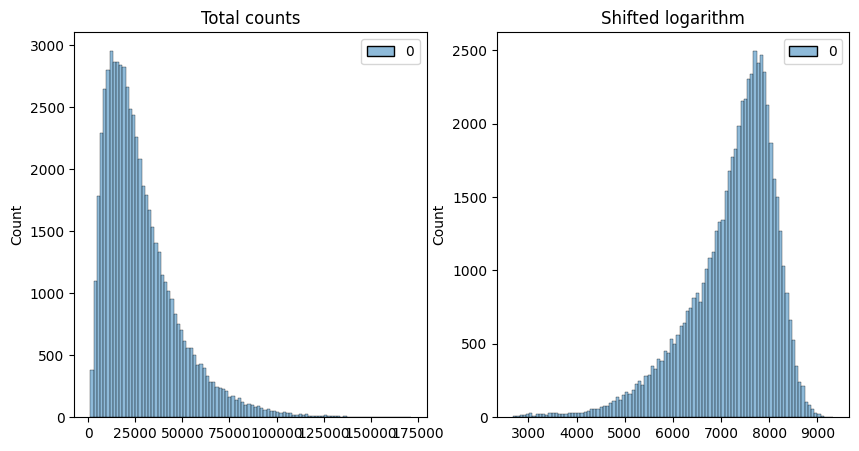

In [10]:
## Log Normalization ##

# set raw_counts
psychad.layers['raw_counts'] = psychad.X

# normalize 
scales_counts = sc.pp.normalize_total(psychad, layer='raw_counts', target_sum=None, inplace=False)

# log1p transform
psychad.layers["log1p_norm"] = sc.pp.log1p(scales_counts["X"], copy=True)

# set X as log1p normed counts
psychad.X = psychad.layers["log1p_norm"]

# recover memory
del scales_counts
gc.collect()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
p1 = sns.histplot(psychad.layers["raw_counts"].sum(1), bins=100, kde=False, ax=axes[0])
axes[0].set_title("Total counts")
p2 = sns.histplot(psychad.layers["log1p_norm"].sum(1), bins=100, kde=False, ax=axes[1])
axes[1].set_title("Shifted logarithm")
plt.show()

In [11]:
## Batched HVG Selection ##

# calculate HVGs on a protein_coding_autosomal only gene list
psychad.var['autosomal'] = ~psychad.var['gene_chrom'].str.contains('X|Y')
psychad.var['robust_protein_coding_autosome'] = psychad.var['autosomal'] & psychad.var['robust_protein_coding']
psychad = psychad[:,psychad.var.robust_protein_coding_autosome].copy()

# sc.pp.highly_variable_genes(scz_adata, layer='log1p_norm', n_top_genes=3000, inplace=True, subset=True)
sc.pp.highly_variable_genes(psychad, layer='log1p_norm', n_top_genes=3000, inplace=True, subset=True)

# # get gene names where highly variable = True
# scz_hvg = scz_adata.var.index[scz_adata.var['highly_variable_features']]
# psych_hvg = psychad.var.index[psychad.var['highly_variable_features']]

# # intersect gene lists
# common_hvg = scz_hvg.intersection(psych_hvg)

# # subset both datasets
# psychad = psychad[:, common_hvg].copy()
# scz_adata = scz_adata[:, common_hvg].copy()

gc.collect()

20215

In [12]:
psychad.shape

(60634, 3000)

In [13]:
# ## Batched HVG Selection ##

# # calculate HVGs on a protein_coding_autosomal only gene list
# psychad.var['autosomal'] = ~psychad.var['gene_chrom'].str.contains('X|Y')
# psychad.var['robust_protein_coding_autosome'] = psychad.var['autosomal'] & psychad.var['robust_protein_coding']
# psychad = psychad[:,psychad.var.robust_protein_coding_autosome].copy()

# # sc.pp.highly_variable_genes(scz_adata, layer='log1p_norm', n_top_genes=3000, inplace=True, subset=True)
# sc.pp.highly_variable_genes(psychad, layer='log1p_norm', n_top_genes=3000, inplace=True, subset=True)

# # get gene names where highly variable = True
# scz_hvg = scz_adata.var.index[scz_adata.var['highly_variable_features']]
# psych_hvg = psychad.var.index[psychad.var['highly_variable_features']]

# # intersect gene lists
# common_hvg = scz_hvg.intersection(psych_hvg)

# # subset both datasets
# psychad = psychad[:, common_hvg].copy()
# scz_adata = scz_adata[:, common_hvg].copy()

# gc.collect()

In [14]:
# Setup Model & Begin Training ##

scvi.model.SCVI.setup_anndata(psychad, layer="raw_counts",     
                              batch_key='Source',
                              categorical_covariate_keys=["SubID", "Sex"],
                              continuous_covariate_keys=["n_counts", "n_genes", "percent_mito"])

model = scvi.model.SCVI(psychad, n_hidden=1024, n_latent=30, n_layers=4)

model.train(max_epochs=30, train_size=0.9, early_stopping=True, batch_size=2048)

#model.train(max_epochs=30, train_size=0.9, early_stopping=True, batch_size=4096, plan_kwargs={"kl_weight": 0.0, "n_epochs_kl_warmup": 5})

/home/deepak/pixi_envs/scanvi/.pixi/envs/default/lib/python3.11/site-packages/scvi/data/fields/_arraylike_field.py:421: UserWarning: Category 40 in adata.obs['SubID'] has fewer than 3 cells. Models may not train properly.
  mapping = _make_column_categorical(df, key, key, categorical_dtype=categorical_dtype)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training:   0%|          | 0/30 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.


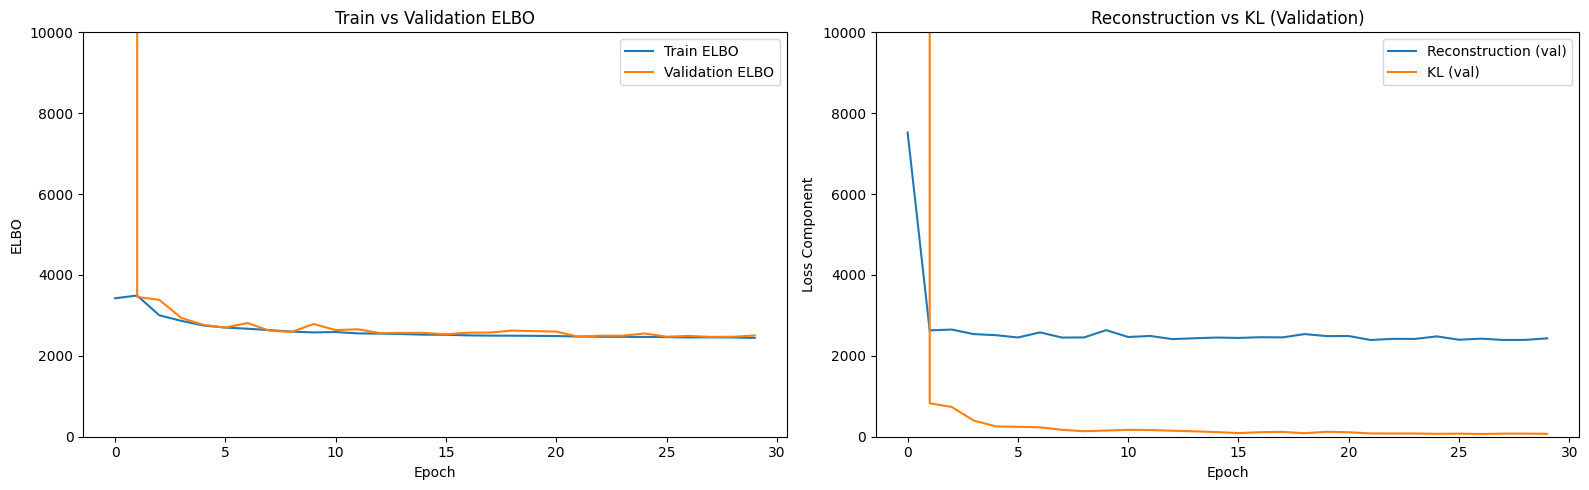

In [15]:
## Examine Train/Val Loss ELBO and Reconstruction/Kullback-Leiber Val Loss

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ---- Left plot: Train vs Validation ELBO ----
axes[0].plot(model.history["elbo_train"], label="Train ELBO")
axes[0].plot(model.history["elbo_validation"], label="Validation ELBO")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("ELBO")
axes[0].set_ylim(0, 10000)
axes[0].set_title("Train vs Validation ELBO")
axes[0].legend()

# ---- Right plot: Reconstruction vs KL ----
axes[1].plot(model.history["reconstruction_loss_validation"], label="Reconstruction (val)")
axes[1].plot(model.history["kl_local_validation"], label="KL (val)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss Component")
axes[1].set_ylim(0, 10000)
axes[1].set_title("Reconstruction vs KL (Validation)")
axes[1].legend()

plt.tight_layout()
plt.show()

In [16]:
## Save and Loading ##

model_dir = os.path.join("/mnt/sdb/scz_meta_analysis_processed/models/psychad_models/", "psychad_scvi")
model.save(model_dir, overwrite=True)

model = scvi.model.SCVI.load(model_dir, adata=psychad)

INFO     File /mnt/sdb/scz_meta_analysis_processed/models/psychad_models/psychad_scvi/model.pt already downloaded  


/home/deepak/pixi_envs/scanvi/.pixi/envs/default/lib/python3.11/site-packages/scvi/data/fields/_arraylike_field.py:421: UserWarning: Category 40 in adata.obs['SubID'] has fewer than 3 cells. Models may not train properly.
  mapping = _make_column_categorical(df, key, key, categorical_dtype=categorical_dtype)


In [17]:
## Save Model Representation ##

psychad.obsm["X_scVI"] = model.get_latent_representation()
psychad.layers["scvi_normalized"] = model.get_normalized_expression(library_size=10e4, batch_size=1024)

In [18]:
## Calculate UMAP With scVI Correction ##

# use scVI latent space for UMAP generation
psychad = UnimodalData(psychad)
pg.neighbors(psychad, rep='scVI', use_cache=False, dist='l2', K=50, n_comps=30)
pg.umap(psychad, rep='scVI', n_neighbors=15, rep_ncomps=30)
psychad.obsm['X_umap_scVI'] = psychad.obsm['X_umap']
psychad = psychad.to_anndata()

2026-04-23 21:08:24,471 - pegasus.tools.nearest_neighbors - INFO - Function 'get_neighbors' finished in 2.91s.
2026-04-23 21:08:25,096 - pegasus.tools.nearest_neighbors - INFO - Function 'calculate_affinity_matrix' finished in 0.63s.
2026-04-23 21:08:25,097 - pegasus.tools.nearest_neighbors - INFO - Found cached kNN results, no calculation is required.
2026-04-23 21:08:25,098 - pegasus.tools.nearest_neighbors - INFO - Function 'get_neighbors' finished in 0.00s.
UMAP(min_dist=0.5, n_jobs=1, precomputed_knn=(array([[    0, 56331, 352, ..., 16964, 40002, 15518],
       [    1, 56507, 13178, ..., 35499, 45107, 52943],
       [    2, 45800, 46367, ..., 59530, 48575, 15164],
       ...,
       [60631, 12449, 59909, ..., 10949, 13762, 20206],
       [60632, 25983, 50558, ..., 36917, 30398, 14222],
       [60633, 1291, 30948, ..., 2248, 1703, 37283]]), array([[0.        , 0.04989037, 0.05486572, ..., 0.11976208, 0.13157836,
        0.13188341],
       [0.        , 0.0281308 , 0.05192483, ..., 

/home/deepak/pixi_envs/scanvi/.pixi/envs/default/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Thu Apr 23 21:08:26 2026 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Thu Apr 23 21:09:00 2026 Finished embedding
2026-04-23 21:09:00,370 - pegasus.tools.visualization - INFO - Function 'umap' finished in 35.27s.


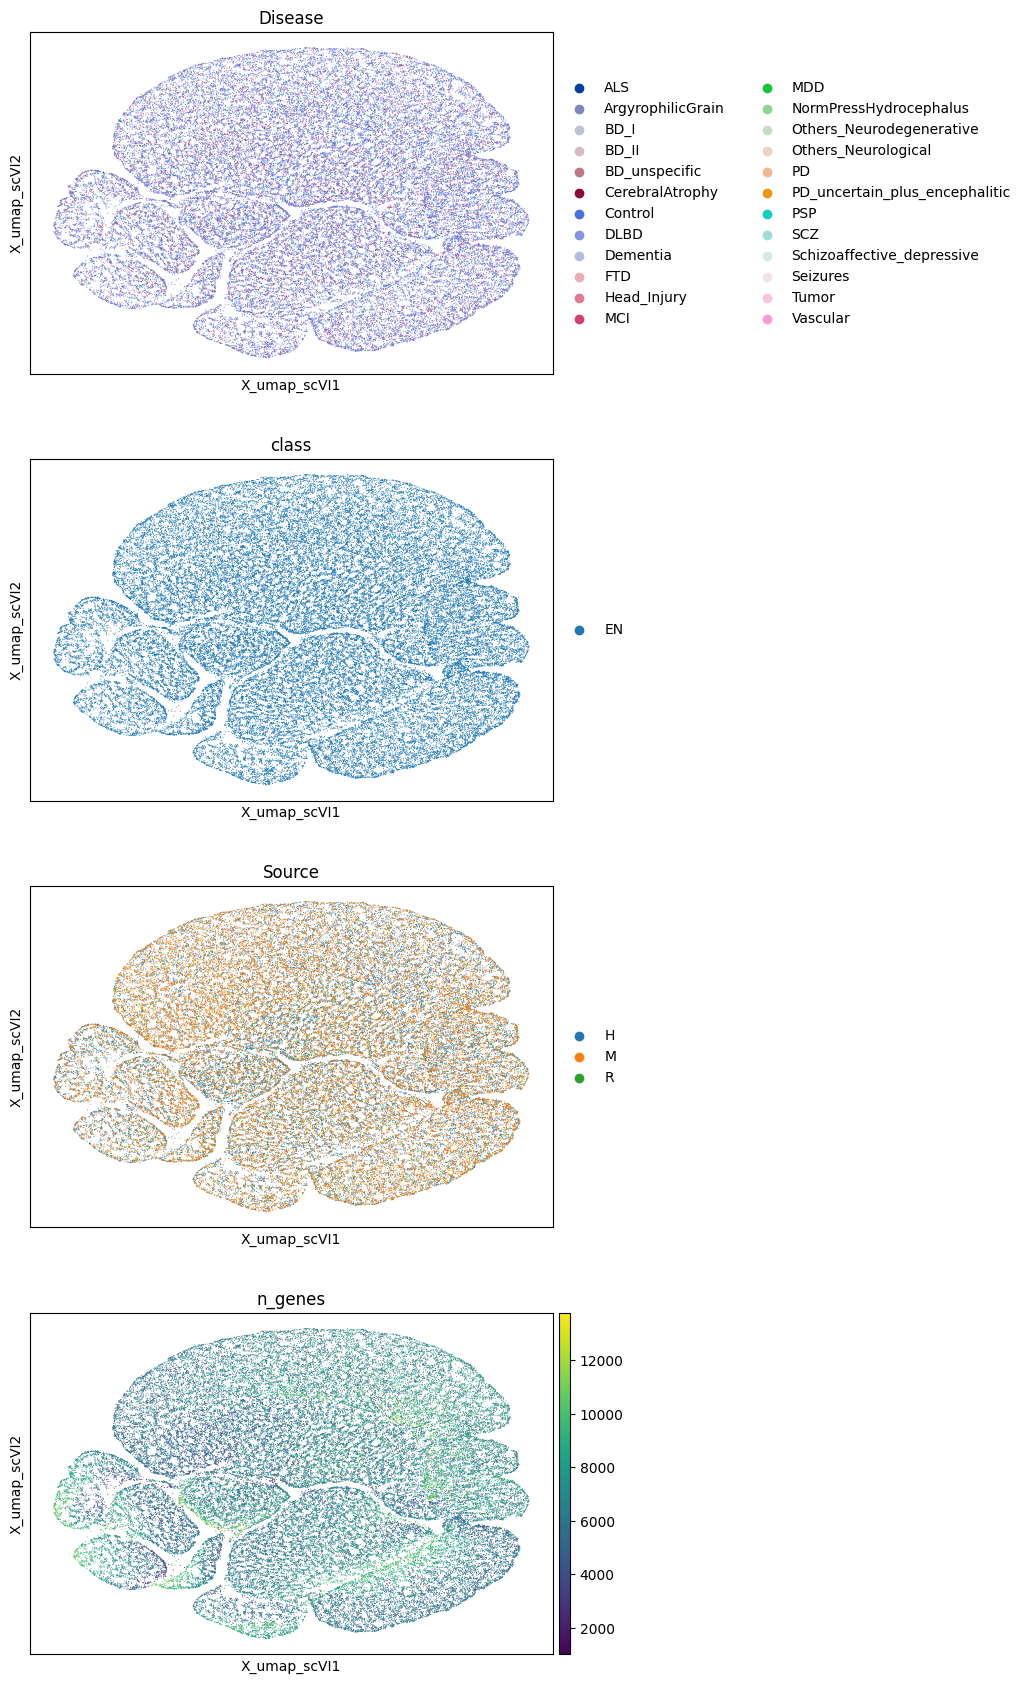

In [19]:
sc.pl.embedding(psychad, basis='X_umap_scVI', color=['Disease', 'class', 'Source', 'n_genes'], ncols=1)

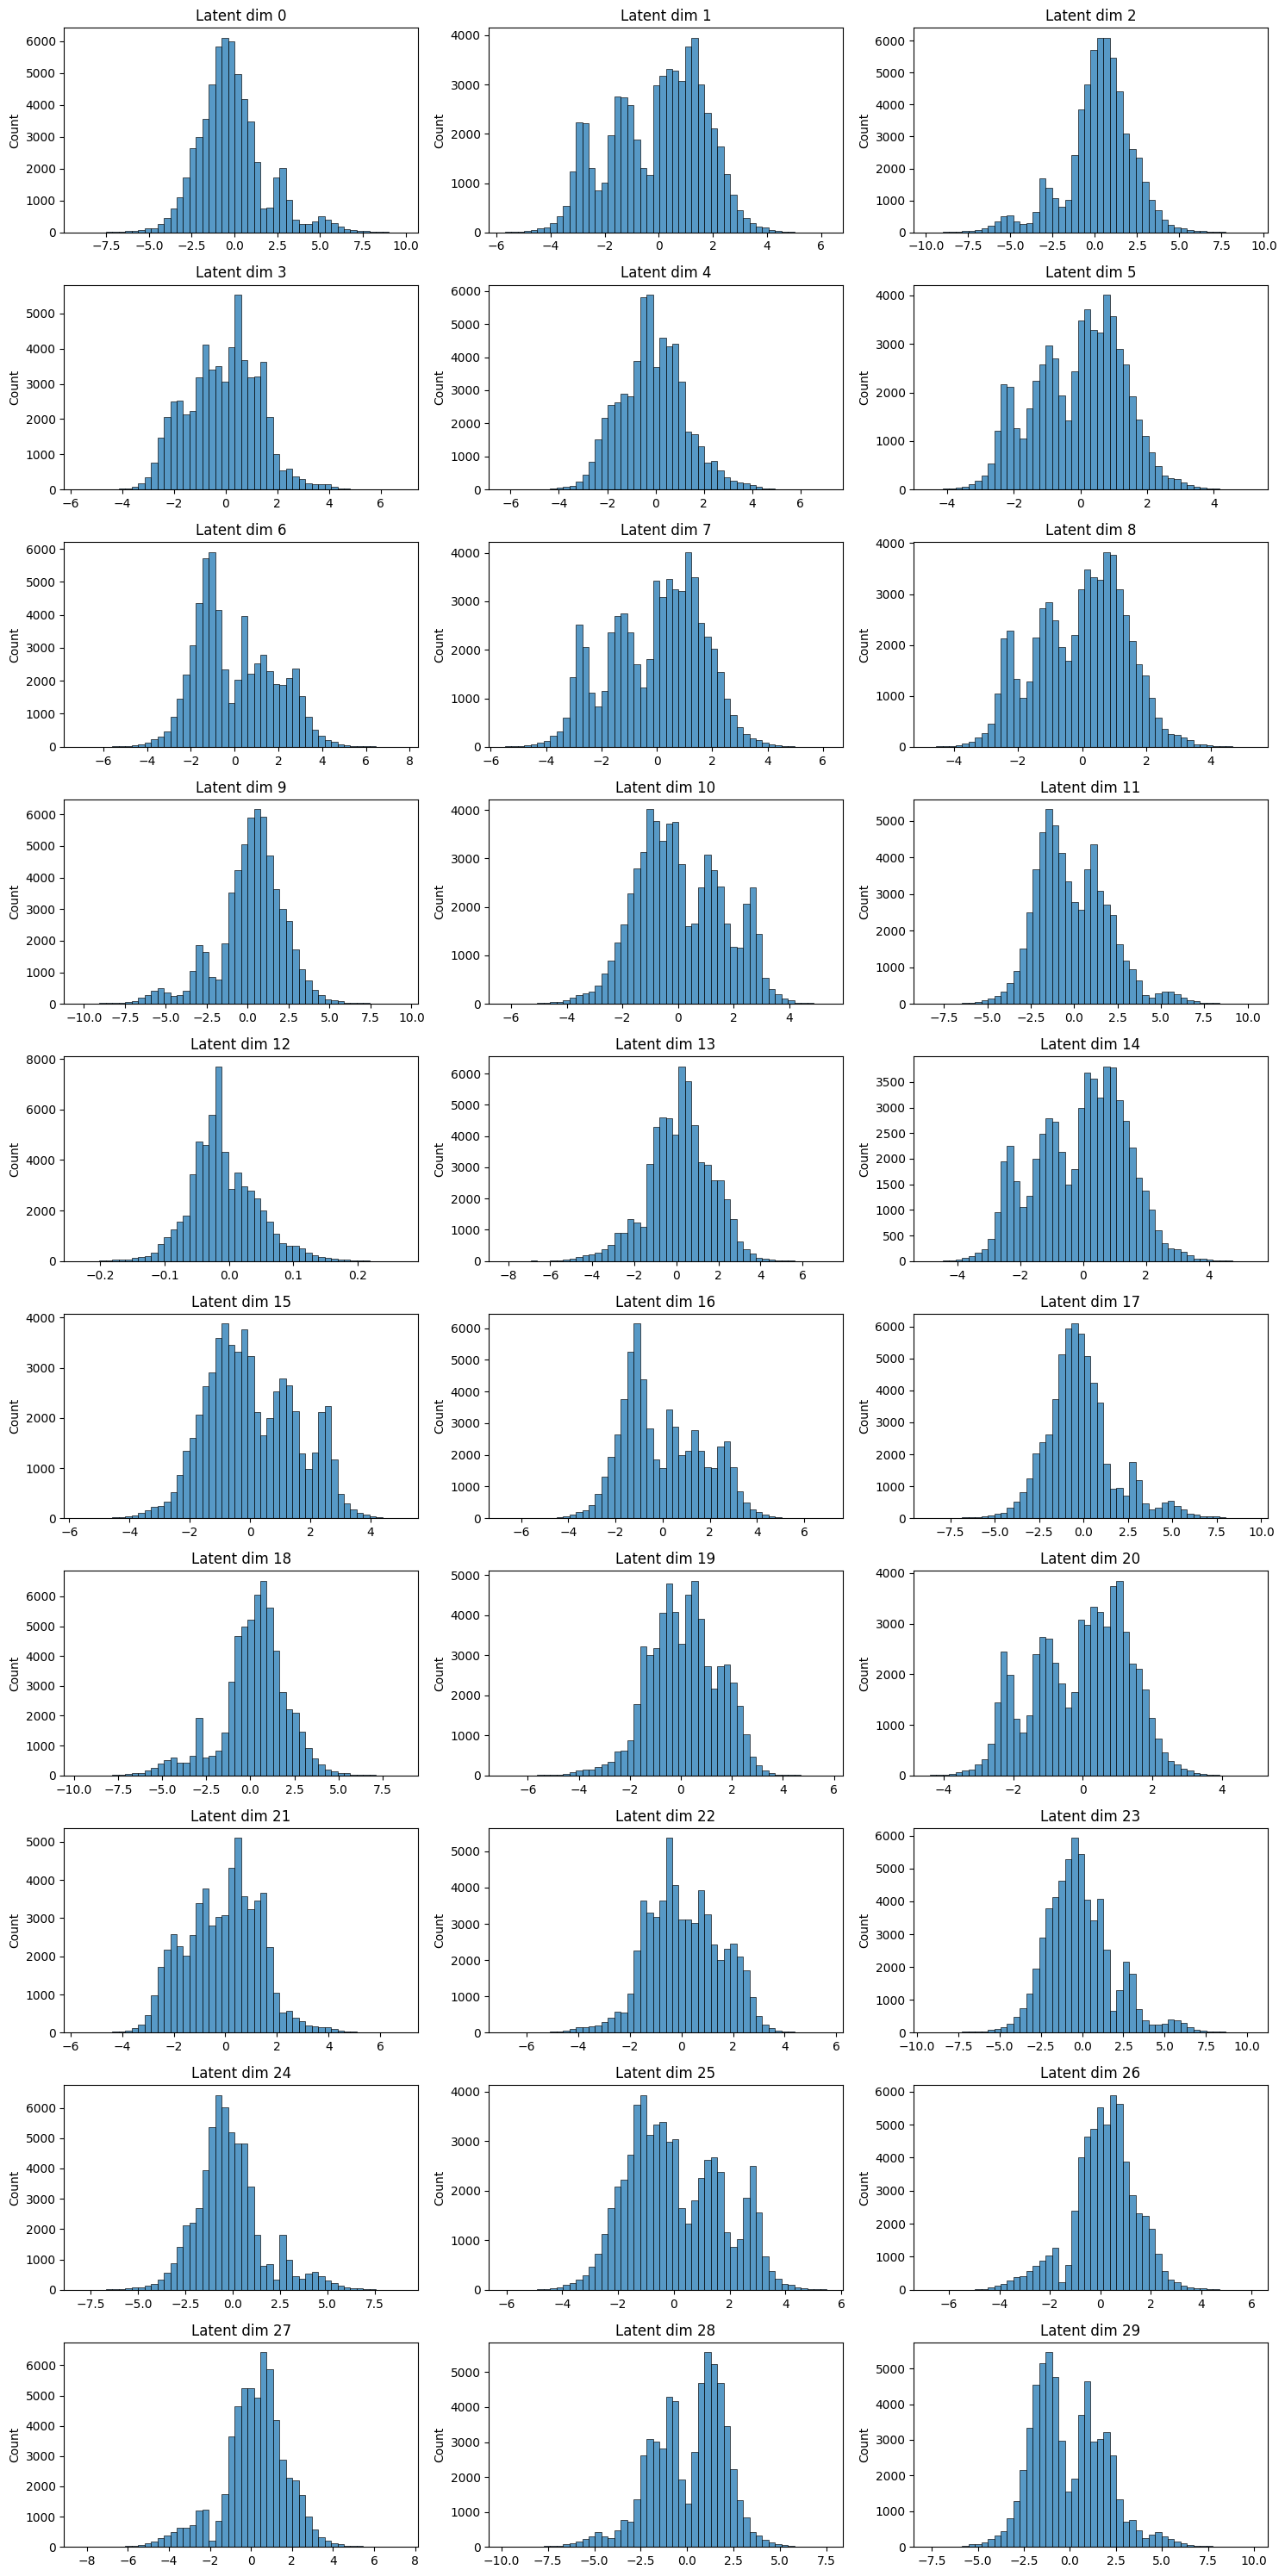

In [20]:
## PLOT LATENT DIMS ##

X = psychad.obsm['X_scVI']
n_dims = X.shape[1]

n_cols = 3
n_rows = int(np.ceil(n_dims / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 3))

axes = axes.flatten()

for i in range(n_dims):
    sns.histplot(X[:, i], ax=axes[i], bins=50)
    axes[i].set_title(f"Latent dim {i}")

# Remove any unused subplots
for j in range(n_dims, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [21]:
## Train Supervised Part of Model ##

psychad.obs['Disease'] = psychad.obs['Disease'].astype(str)

scanvi_model = scvi.model.SCANVI.from_scvi_model(model, adata=psychad,
                                                 labels_key="Disease",
                                                 unlabeled_category="Unknown")

scanvi_model.train(max_epochs=30, batch_size=2048, plan_kwargs={"lr": 1e-4})

scanvi_model.save("/mnt/sdb/scz_meta_analysis_processed/models/psychad_models/psychad_scvi/", overwrite=True)

INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/home/deepak/pixi_envs/scanvi/.pixi/envs/default/lib/python3.11/site-packages/scvi/data/fields/_arraylike_field.py:421: UserWarning: Category 40 in adata.obs['SubID'] has fewer than 3 cells. Models may not train properly.
  mapping = _make_column_categorical(df, key, key, categorical_dtype=categorical_dtype)
/home/deepak/pixi_envs/scanvi/.pixi/envs/default/lib/python3.11/site-packages/scvi/data/fields/_arraylike_field.py:421: UserWarning: Category 40 in adata.obs['SubID'] has fewer than 3 cells. Models may not train properly.
  mapping = _make_column_categorical(df, key, key, categorical_dtype=categorical_dtype)


INFO     Training for 30 epochs.                                                                                   


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training:   0%|          | 0/30 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.


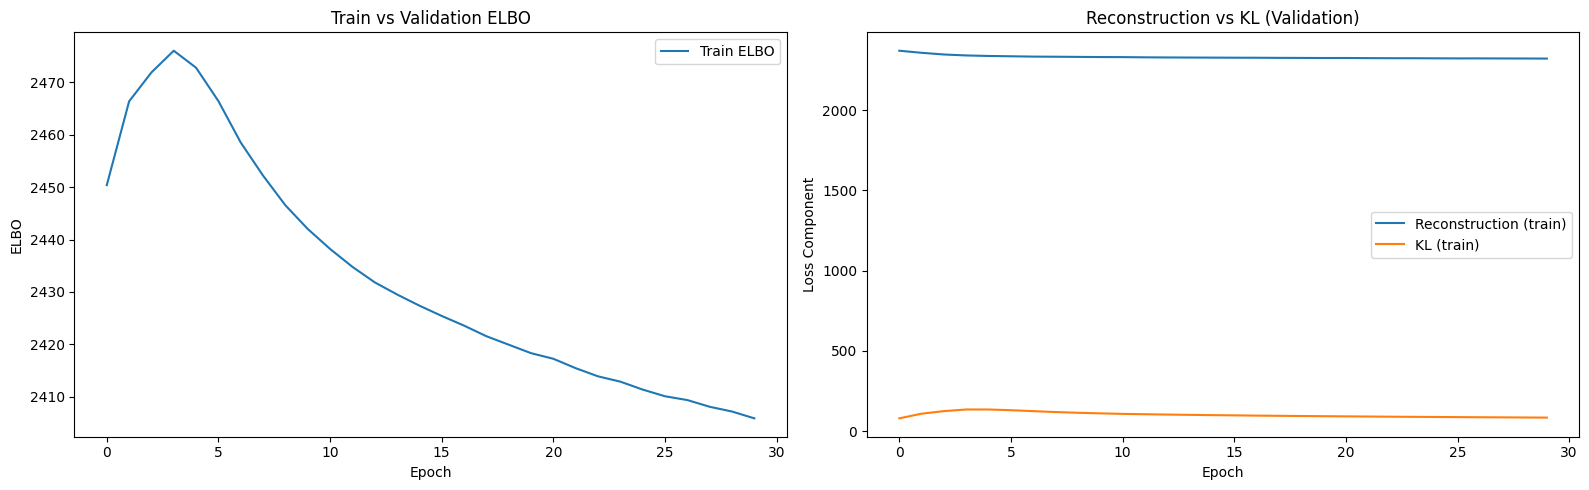

In [22]:
## Examine Train/Val Loss ELBO and Reconstruction/Kullback-Leiber Val Loss

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ---- Left plot: Train vs Validation ELBO ----
axes[0].plot(scanvi_model.history["elbo_train"], label="Train ELBO")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("ELBO")
axes[0].set_title("Train vs Validation ELBO")
axes[0].legend()

# ---- Right plot: Reconstruction vs KL ----
axes[1].plot(scanvi_model.history["reconstruction_loss_train"], label="Reconstruction (train)")
axes[1].plot(scanvi_model.history["kl_local_train"], label="KL (train)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss Component")
axes[1].set_title("Reconstruction vs KL (Validation)")
axes[1].legend()

plt.tight_layout()
plt.show()

In [23]:
## Calculate UMAP With scANVI Update ##

psychad.obsm["X_scANVI"] = scanvi_model.get_latent_representation(psychad)

# use scVI latent space for UMAP generation
psychad = UnimodalData(psychad)
pg.neighbors(psychad, rep='scANVI', use_cache=False, dist='l2', K=50, n_comps=30)
pg.umap(psychad, rep='scANVI', n_neighbors=15, rep_ncomps=30)
psychad.obsm['X_umap_scANVI'] = psychad.obsm['X_umap']
psychad = psychad.to_anndata()

2026-04-23 21:14:28,487 - pegasus.tools.nearest_neighbors - INFO - Function 'get_neighbors' finished in 3.00s.
2026-04-23 21:14:29,090 - pegasus.tools.nearest_neighbors - INFO - Function 'calculate_affinity_matrix' finished in 0.60s.
2026-04-23 21:14:29,091 - pegasus.tools.nearest_neighbors - INFO - Found cached kNN results, no calculation is required.
2026-04-23 21:14:29,092 - pegasus.tools.nearest_neighbors - INFO - Function 'get_neighbors' finished in 0.00s.
UMAP(min_dist=0.5, n_jobs=1, precomputed_knn=(array([[    0, 35590, 33423, ..., 56982, 46535, 41972],
       [    1, 4104, 41288, ..., 50063, 60431, 52460],
       [    2, 25118, 9248, ..., 29915, 59731, 55319],
       ...,
       [60631, 52547, 30146, ..., 25772, 51644, 2900],
       [60632, 28700, 18186, ..., 37431, 15820, 14720],
       [60633, 9884, 60366, ..., 30787, 31899, 12156]]), array([[0.        , 0.14363736, 0.18868145, ..., 0.36404997, 0.40097022,
        0.41622669],
       [0.        , 0.14436488, 0.2023605 , ...,

/home/deepak/pixi_envs/scanvi/.pixi/envs/default/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Thu Apr 23 21:14:59 2026 Finished embedding
2026-04-23 21:14:59,083 - pegasus.tools.visualization - INFO - Function 'umap' finished in 29.99s.


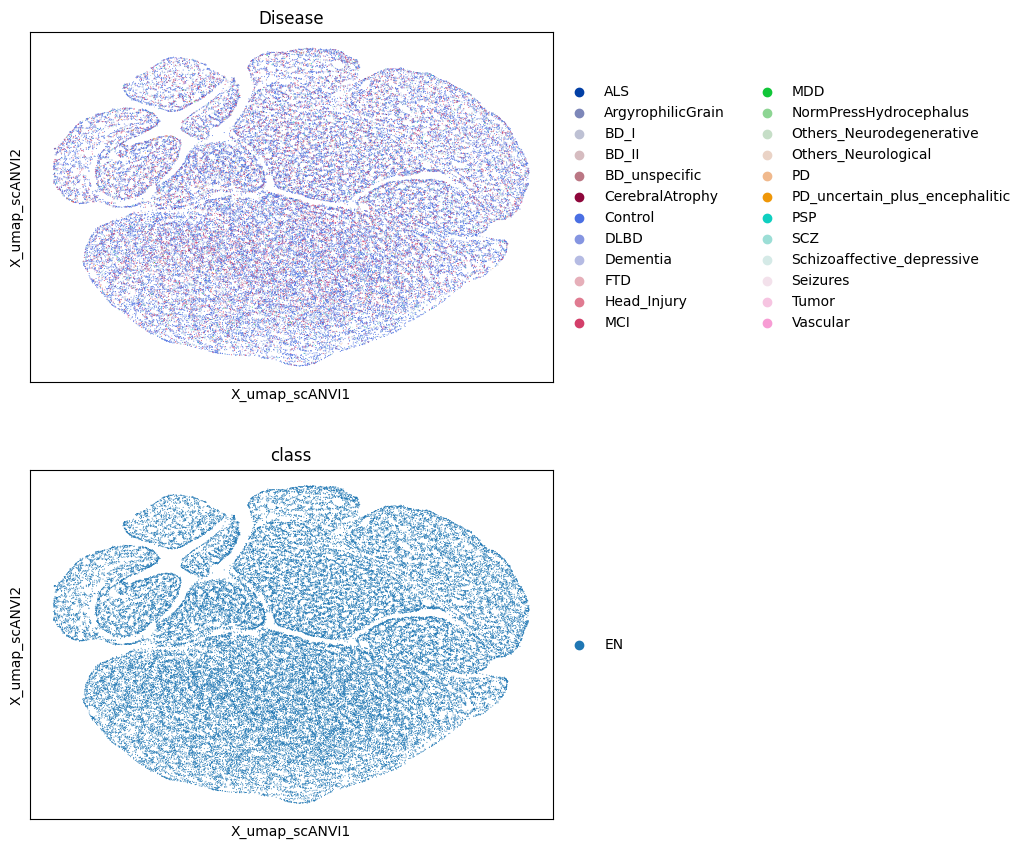

In [24]:
sc.pl.embedding(psychad, basis='X_umap_scANVI', color=['Disease', 'class'], ncols=1)

IndexError: index 15 is out of bounds for axis 1 with size 15

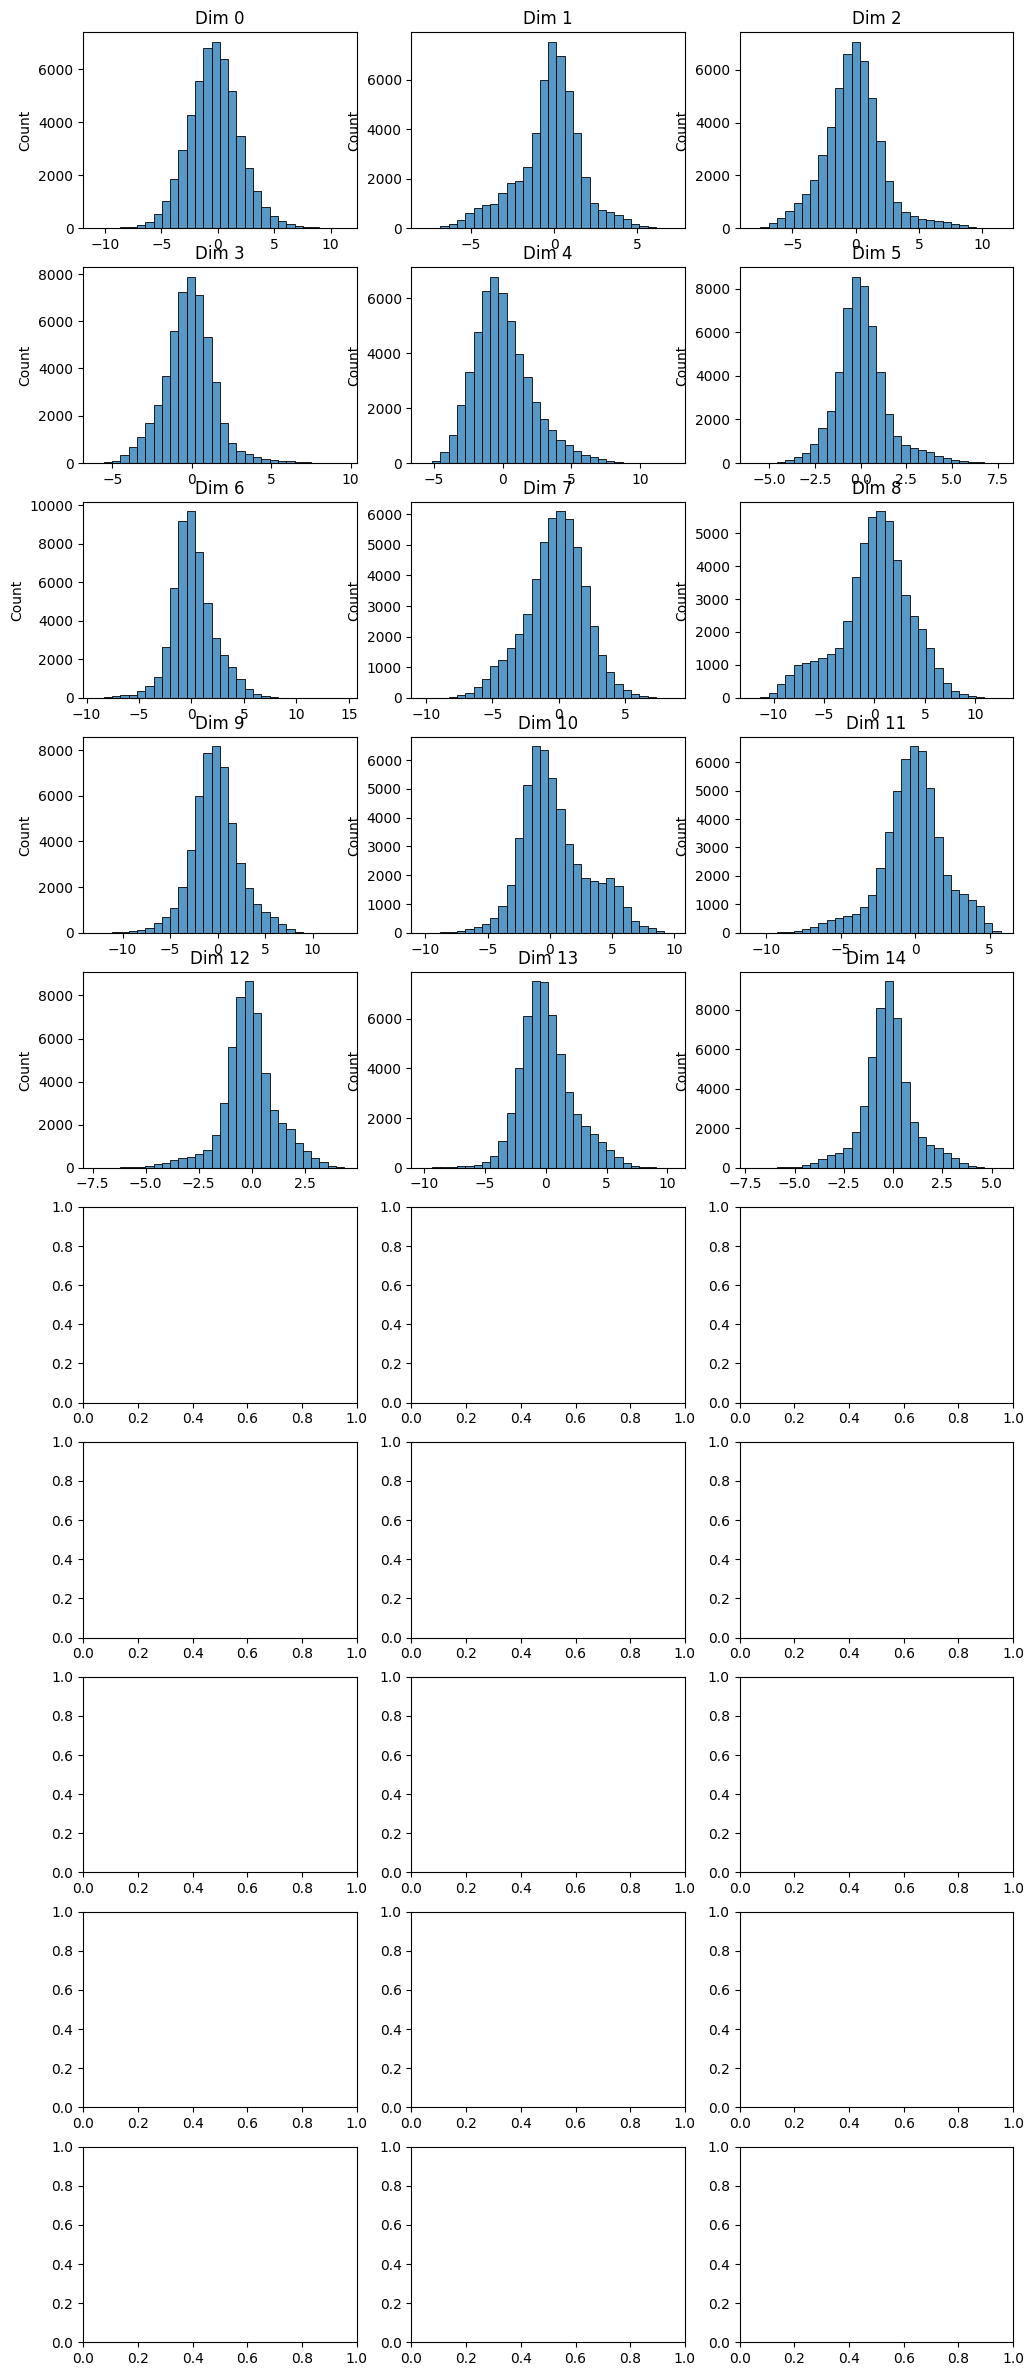

In [25]:
## EXAMINE SCANVI LATENTS ##

data = psychad.obsm['X_scANVI']

fig, axes = plt.subplots(10, 3, figsize=(12, 30))
axes = axes.flatten()

for i in range(30):
    sns.histplot(data[:, i], ax=axes[i], bins=30)
    axes[i].set_title(f'Dim {i}')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

X = scanvi_model.get_latent_representation()
y = psychad.obs["Disease"].values

clf = LogisticRegression(max_iter=2000)

scores = cross_val_score(clf, X, y, cv=5, scoring="accuracy")

print(scores)
print("mean accuracy:", scores.mean())

In [26]:
## Update With Query ##

scvi.model.SCANVI.prepare_query_anndata(scz_adata, scanvi_model)

scanvi_model_q = scvi.model.SCANVI.load_query_data(scz_adata, scanvi_model)
scanvi_model_q.train(max_epochs=5, plan_kwargs={"weight_decay": 0.0, "lr": 1e-4}) #, check_val_every_n_epoch=10) # max_epochs=200
scanvi_model_q.save("/mnt/sdb/scz_meta_analysis_processed/models/psychad_models/psychad_scanvi_query_update/", overwrite=True)

INFO     Found 83.06666666666666% reference vars in query data.                                                    


KeyboardInterrupt: 

In [ ]:
query_ref.obs[['n_counts', 'n_genes', 'class', 'Source', 'SubID', 'Disease', 'Sex']].value_counts()

In [ ]:
query_ref = sc.concat([scz_adata, psychad], axis=0, label='origin', keys=['kaji', 'psychad'], join='outer')

query_ref.obs["Pred_PsychAD_Disease"] = scanvi_model_q.predict(query_ref)

In [ ]:
## Get Latent Representation ##

query_ref.obsm["X_scANVI"] = scanvi_model_q.get_latent_representation(query_ref)

query_ref = UnimodalData(query_ref)
pg.neighbors(query_ref, rep='scANVI', use_cache=False, dist='l2', K=50, n_comps=30)
pg.umap(query_ref, rep='scANVI', n_neighbors=15, rep_ncomps=30)
query_ref.obsm['X_umap_scANVI'] = query_ref.obsm['X_umap']

query_ref = query_ref.to_anndata()

In [ ]:
sc.pl.embedding(query_ref, basis='X_umap_scANVI', color=['Disease', 'class', 'origin'], ncols=1)

In [ ]:
query_ref.write_h5ad('/mnt/sdb/scz_meta_analysis_processed/anndata_objs/scz_adata_psychad_query_ref.h5ad')

In [ ]:
## Adata add ["X_scANVI","Pred_Celltype"] ##

scz_adata.obsm["X_scANVI"] = scanvi_model_q.get_latent_representation(scz_adata)

scz_adata.obs["Pred_PsychAD_Disease"] = scanvi_model_q.predict(scz_adata)

scz_adata.write_h5ad('/mnt/sdb/scz_meta_analysis_processed/anndata_objs/scz_adata_only_with_psychad_pred.h5ad')